In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.base import BaseEstimator, clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder, PolynomialFeatures
from sklearn.feature_selection import chi2, VarianceThreshold, SelectKBest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import EditedNearestNeighbours, CondensedNearestNeighbour, NearMiss
from imblearn.pipeline import Pipeline
import umap.umap_ as umap

!pip install optuna

import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_param_importances

import time

seed=42

In [4]:
df = pd.read_csv('covtype_decoded.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           581012 non-null  int64 
 1   Aspect                              581012 non-null  int64 
 2   Slope                               581012 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64 
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64 
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64 
 6   Hillshade_9am                       581012 non-null  int64 
 7   Hillshade_Noon                      581012 non-null  int64 
 8   Hillshade_3pm                       581012 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64 
 10  Wilderness                          581012 non-null  object
 11  Soil_Type                           581

In [6]:
num = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']
cat = [ 'Wilderness', 'Soil_Type']

In [7]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.02,random_state=seed,stratify=y)

In [9]:
print('X_train shape ', X_train.shape)
print('X_test shape ', X_test.shape)

X_train shape  (569391, 12)
X_dev shape  (5811, 12)
X_test shape  (5810, 12)


In [10]:
le = LabelEncoder()
y_train_nc = le.fit_transform(y_train)
y_test_nc = le.fit_transform(y_test)

In [11]:
te = ColumnTransformer([
    ('te', TargetEncoder().set_output(transform='pandas'), cat)
],verbose_feature_names_out=False,remainder='passthrough').set_output(transform='pandas')

preprocessing = Pipeline([
    ('te', te),
    ('ss', StandardScaler().set_output(transform='pandas')),
    ('poly',PolynomialFeatures(degree=2,include_bias=False).set_output(transform='pandas'))
])

X_train_poly = preprocessing.fit_transform(X_train,y_train)

In [12]:
def model_trainer(model,model_params,X,y,n_trials=30):
    def objective(trial):
        params = model_params(trial)
        model.set_params(**params)
        stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        score = cross_val_score(model, X, y, cv=stratified_cv, scoring='f1_micro').mean()
        return score

    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective,n_trials=n_trials)

    model.set_params(**study.best_trial.params)
    model.fit(X,y)

    return study, model

In [15]:
sgd = SGDClassifier(loss='log_loss',
                    random_state=seed,
                    n_jobs=-1,
                    class_weight='balanced',
                    early_stopping=True,
                    validation_fraction=0.2,
                    max_iter=10000,
                    # verbose=1
                    )

def sgd_params(trial):
    return {
        'penalty':trial.suggest_categorical('penalty',['l2','l1','elasticnet']),
        'alpha':trial.suggest_float('alpha',1e-4,1,log=True),
        'l1_ratio':trial.suggest_float('l1_ratio',0,1),
        'learning_rate':trial.suggest_categorical('learning_rate',['constant','optimal','invscaling','adaptive']),
        'eta0':trial.suggest_float('eta0',1e-4,1,log=True),
        'power_t':trial.suggest_float('power_t',0,1)
    }

sgd_study, sgd_model = model_trainer(sgd,sgd_params,X_train_poly,y_train_nc,n_trials=30)

[I 2025-05-10 10:12:35,399] A new study created in memory with name: no-name-8cd9b505-58c8-4924-97c1-de134399293e


Norm: 1261.29, NNZs: 12, Bias: -6.882481, T: 2186454, Avg. loss: 1.062142
Total training time: 31.04 seconds.
-- Epoch 7
Norm: 6830.13, NNZs: 4, Bias: -52.998230, T: 2550863, Avg. loss: 7.071719
Total training time: 37.32 seconds.
Convergence after 7 epochs took 37.47 seconds
Norm: 1357.77, NNZs: 9, Bias: -2.156948, T: 2550863, Avg. loss: 1.142599
Total training time: 38.98 seconds.
-- Epoch 8
Norm: 1446.10, NNZs: 10, Bias: -3.702717, T: 2915272, Avg. loss: 1.003689
Total training time: 45.17 seconds.
-- Epoch 9
Norm: 1530.49, NNZs: 6, Bias: -3.292674, T: 3279681, Avg. loss: 1.062481
Total training time: 50.48 seconds.
Convergence after 9 epochs took 50.56 seconds


[I 2025-05-10 10:19:59,680] Trial 0 finished with value: 0.6215113404279877 and parameters: {'penalty': 'l1', 'alpha': 0.024810409748678097, 'l1_ratio': 0.15601864044243652, 'learning_rate': 'invscaling', 'eta0': 0.06796578090758151, 'power_t': 0.020584494295802447}. Best is trial 0 with value: 0.6215113404279877.
[I 2025-05-10 10:24:22,156] Trial 1 finished with value: 0.700158577282777 and parameters: {'penalty': 'l2', 'alpha': 0.000533703276260396, 'l1_ratio': 0.18340450985343382, 'learning_rate': 'optimal', 'eta0': 0.0280163515871626, 'power_t': 0.13949386065204183}. Best is trial 1 with value: 0.700158577282777.
[I 2025-05-10 10:46:13,318] Trial 2 finished with value: 0.6369700239960946 and parameters: {'penalty': 'elasticnet', 'alpha': 0.13826232179369857, 'l1_ratio': 0.19967378215835974, 'learning_rate': 'adaptive', 'eta0': 0.00048094619675015767, 'power_t': 0.06505159298527952}. Best is trial 1 with value: 0.700158577282777.
[I 2025-05-10 10:53:25,610] Trial 3 finished with val

In [16]:
plot_parallel_coordinate(sgd_study).show()

In [18]:
plot_param_importances(sgd_study).show()

In [19]:
y_train_pred = sgd_model.predict(X_train_poly)

In [20]:
print(classification_report(y_train,le.inverse_transform(y_train_pred)))

                   precision    recall  f1-score   support

            Aspen       0.24      0.56      0.34      9303
Cottonwood/Willow       0.39      0.88      0.54      2692
      Douglas-fir       0.46      0.59      0.52     17020
        Krummholz       0.64      0.84      0.72     20100
   Lodgepole Pine       0.80      0.73      0.76    277634
   Ponderosa Pine       0.71      0.73      0.72     35039
       Spruce/Fir       0.73      0.72      0.72    207603

         accuracy                           0.72    569391
        macro avg       0.57      0.72      0.62    569391
     weighted avg       0.74      0.72      0.73    569391



In [23]:
X_test_pp = preprocessing.transform(X_test)
y_test_pred = sgd_model.predict(X_test_pp)

In [24]:
print(classification_report(y_test,le.inverse_transform(y_test_pred)))

                   precision    recall  f1-score   support

            Aspen       0.22      0.52      0.31        95
Cottonwood/Willow       0.36      0.96      0.53        28
      Douglas-fir       0.45      0.53      0.49       174
        Krummholz       0.60      0.82      0.69       205
   Lodgepole Pine       0.80      0.74      0.77      2833
   Ponderosa Pine       0.71      0.72      0.71       357
       Spruce/Fir       0.73      0.70      0.71      2118

         accuracy                           0.72      5810
        macro avg       0.55      0.71      0.60      5810
     weighted avg       0.74      0.72      0.72      5810



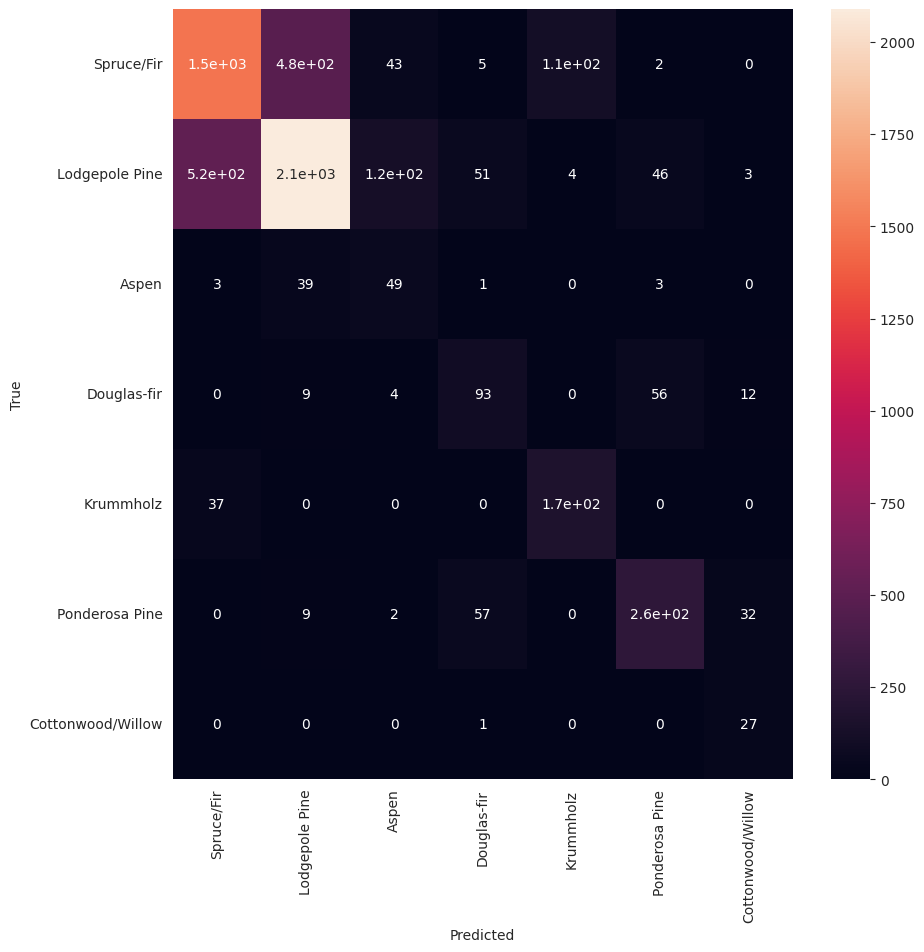

In [26]:
plt.figure(figsize=(10,10))
cm = confusion_matrix(y_test,le.inverse_transform(y_test_pred),labels=y_test.unique())
cm_hm = sns.heatmap(cm,annot=True)
cm_hm.set_xticklabels(y_test.unique(),rotation=90)
cm_hm.set_yticklabels(y_test.unique(),rotation=0)
cm_hm.set_xlabel('Predicted')
cm_hm.set_ylabel('True')
plt.show()

In [30]:
mistake_filter = y_test != le.inverse_transform(y_test_pred)

In [41]:
umap_reducer = umap.UMAP(random_state=seed)
reduced = umap_reducer.fit_transform(X_test_pp)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



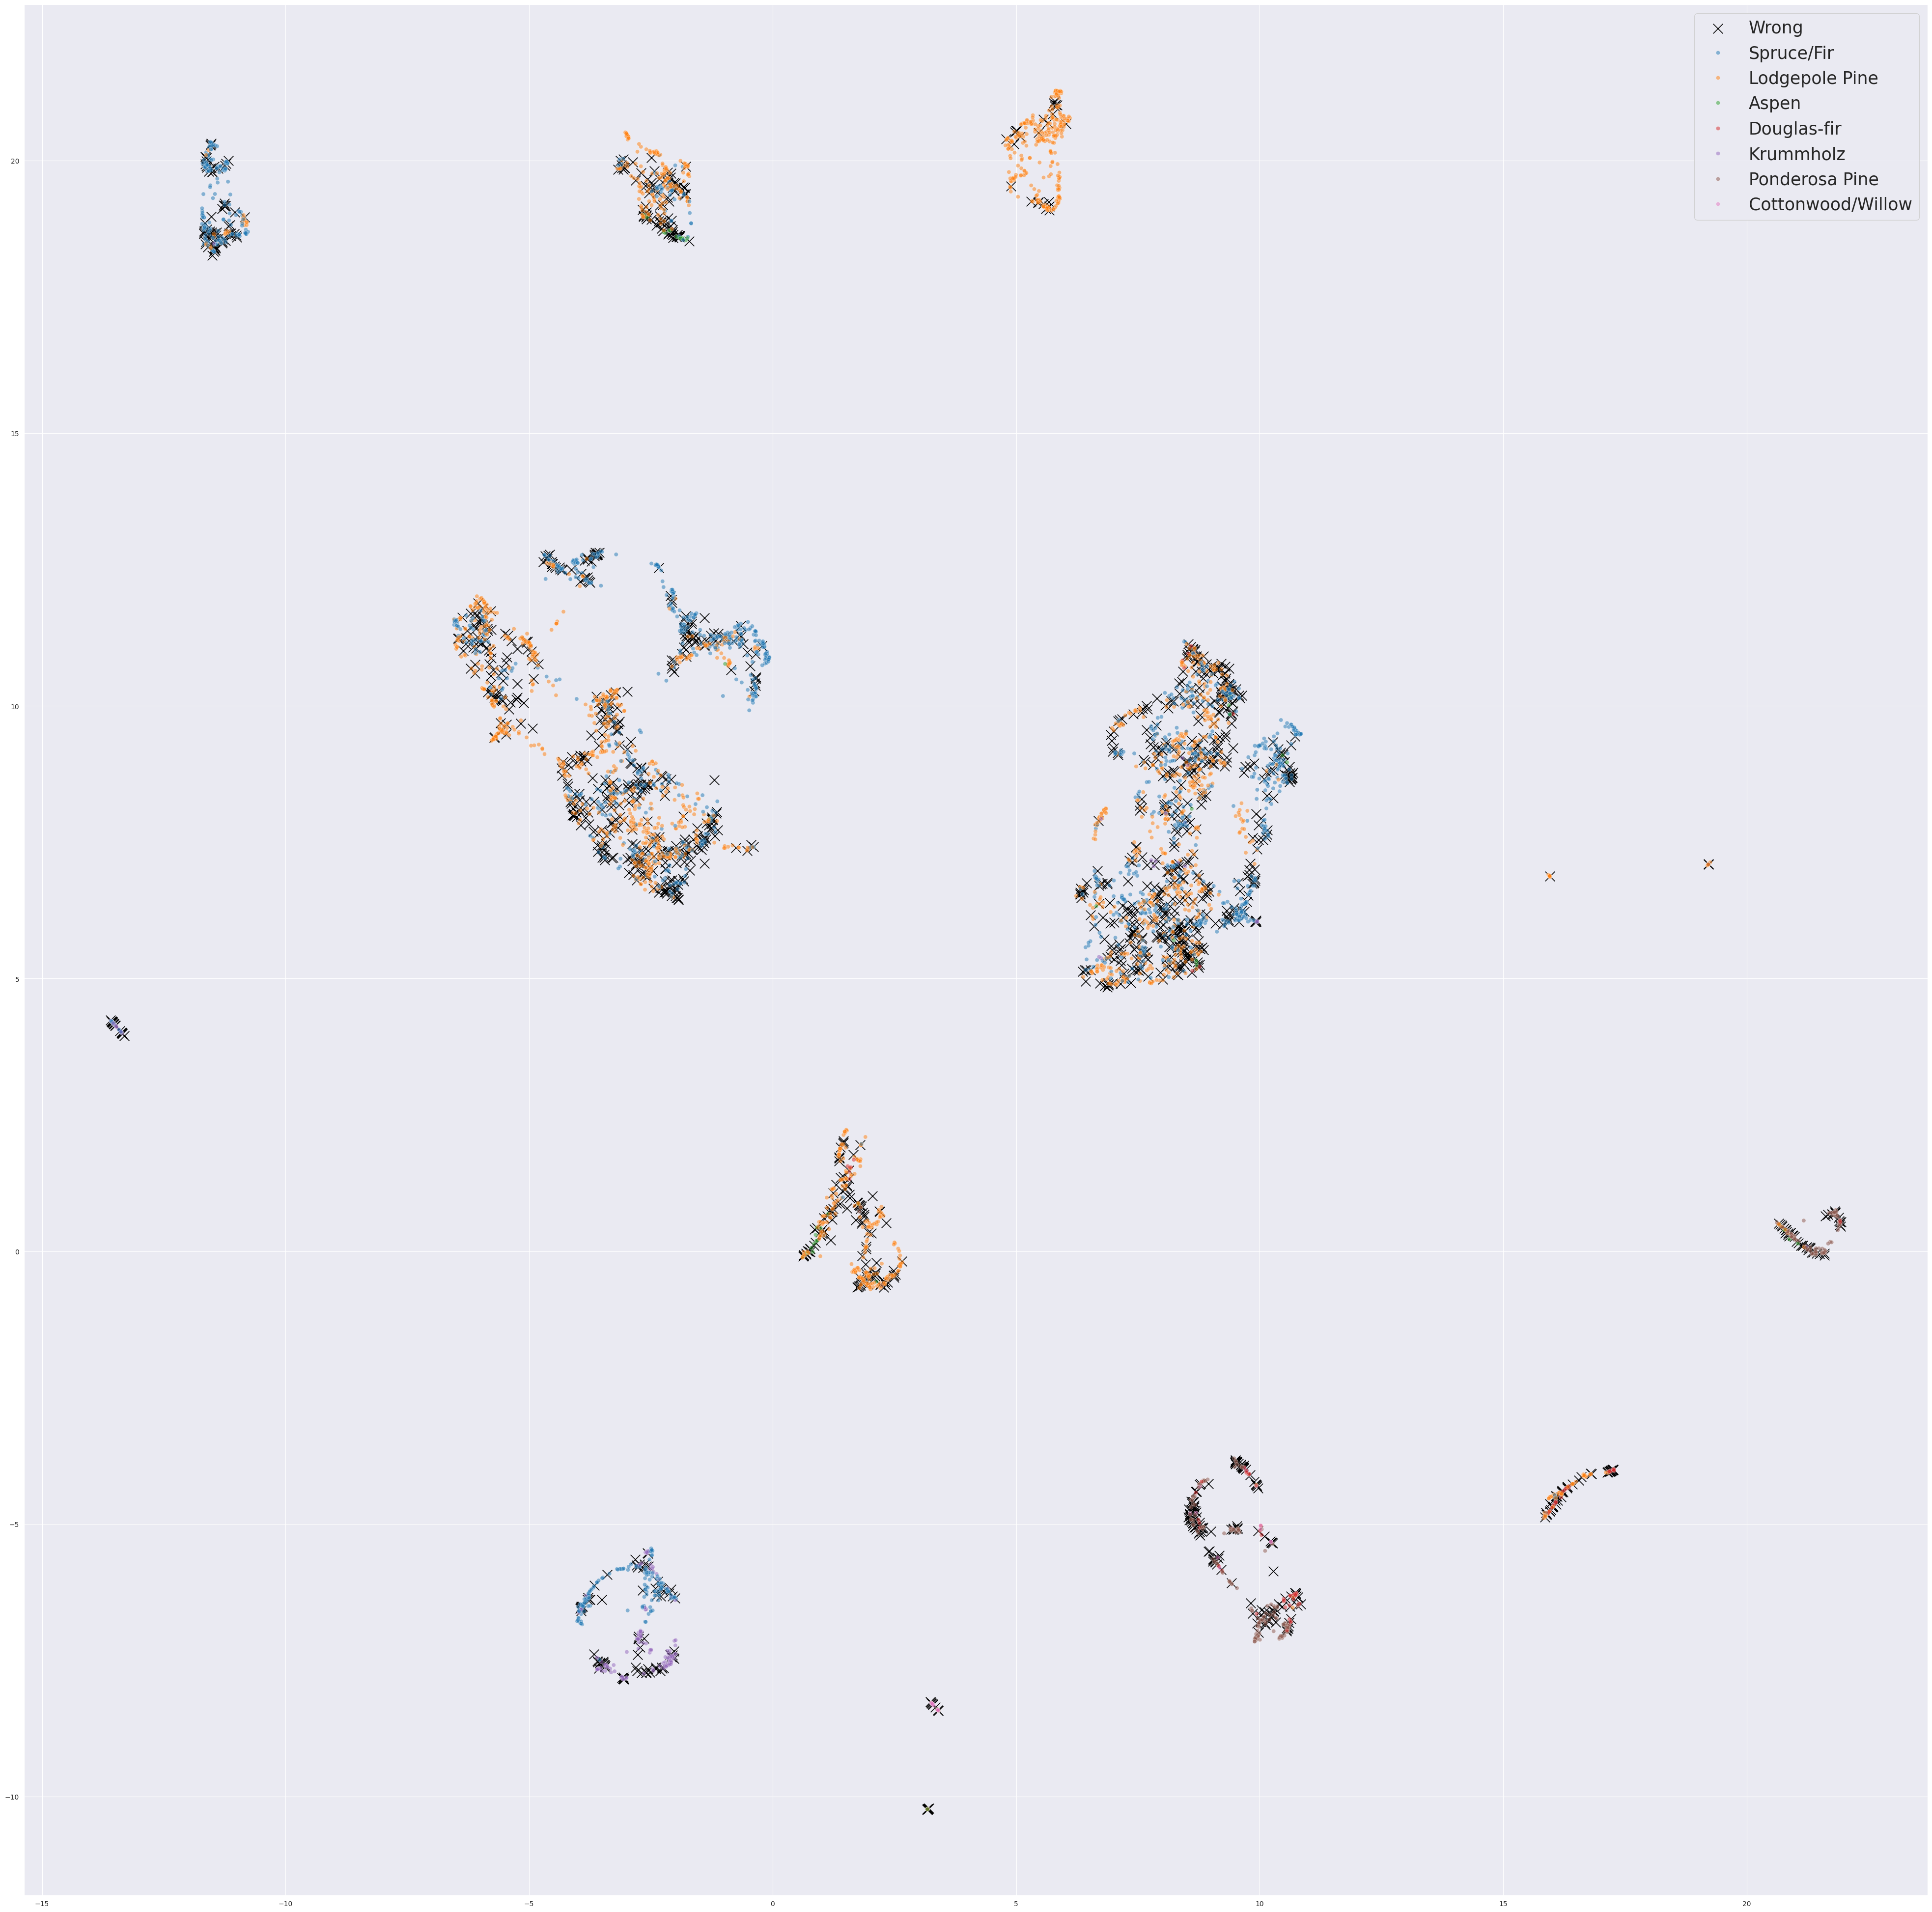

In [56]:
plt.figure(figsize=(50,50))
wrong = sns.scatterplot(x=reduced[mistake_filter,0],y=reduced[mistake_filter,1],c='black',marker='x',s=200,alpha=1,label='Wrong')
right = sns.scatterplot(x=reduced[~mistake_filter,0],y=reduced[~mistake_filter,1],hue=y_test[~mistake_filter],marker='o',alpha=0.5)
plt.legend(fontsize=25)
plt.show()